## 1. Preparar datos

Importa librerias, carga Fashion MNIST, define las clases y normaliza las imagenes.


In [84]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [85]:
# Descargar set de datos de Fashion MNIST de Zalando
# Se usa tf.keras.datasets para evitar conflictos de protobuf con tensorflow_datasets en Colab.
(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_pruebas, etiquetas_pruebas) = tf.keras.datasets.fashion_mnist.load_data()

# Agregar el canal de color: (28, 28) -> (28, 28, 1)
imagenes_entrenamiento = imagenes_entrenamiento[..., np.newaxis]
imagenes_pruebas = imagenes_pruebas[..., np.newaxis]

datos_entrenamiento = tf.data.Dataset.from_tensor_slices((imagenes_entrenamiento, etiquetas_entrenamiento))
datos_pruebas = tf.data.Dataset.from_tensor_slices((imagenes_pruebas, etiquetas_pruebas))


In [86]:
# Revisar las dimensiones del set de datos
print("Entrenamiento:", imagenes_entrenamiento.shape, etiquetas_entrenamiento.shape)
print("Pruebas:", imagenes_pruebas.shape, etiquetas_pruebas.shape)


Entrenamiento: (60000, 28, 28, 1) (60000,)
Pruebas: (10000, 28, 28, 1) (10000,)


In [87]:
# Los datos ya quedaron separados en datos_entrenamiento y datos_pruebas en la celda anterior.


In [88]:
# Etiquetas de las 10 categorias posibles
nombres_clases = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


In [89]:
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [90]:
#Funcion de normalizacion para los datos (Pasar de 0-255 a 0-1)
#Hace que la red aprenda mejor y mas rapido
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 #Aqui lo pasa de 0-255 a 0-1
  return imagenes, etiquetas

#Normalizar los datos de entrenamiento y pruebas con la funcion que hicimos
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar a cache (usar memoria en lugar de disco, entrenamiento mas rapido)
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

## 2. Ver ejemplos

Muestra algunas imagenes del conjunto para revisar como son los datos antes de entrenar.


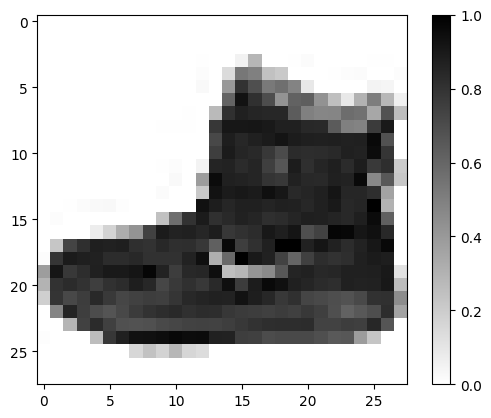

In [91]:
#Mostrar una imagen de los datos de pruebas, de momento mostremos la primera
for imagen, etiqueta in datos_entrenamiento.take(1):
  break
imagen = imagen.numpy().reshape((28,28)) #Redimensionar, cosas de tensores, lo veremos despues

import matplotlib.pyplot as plt

#Dibujar dibujar
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

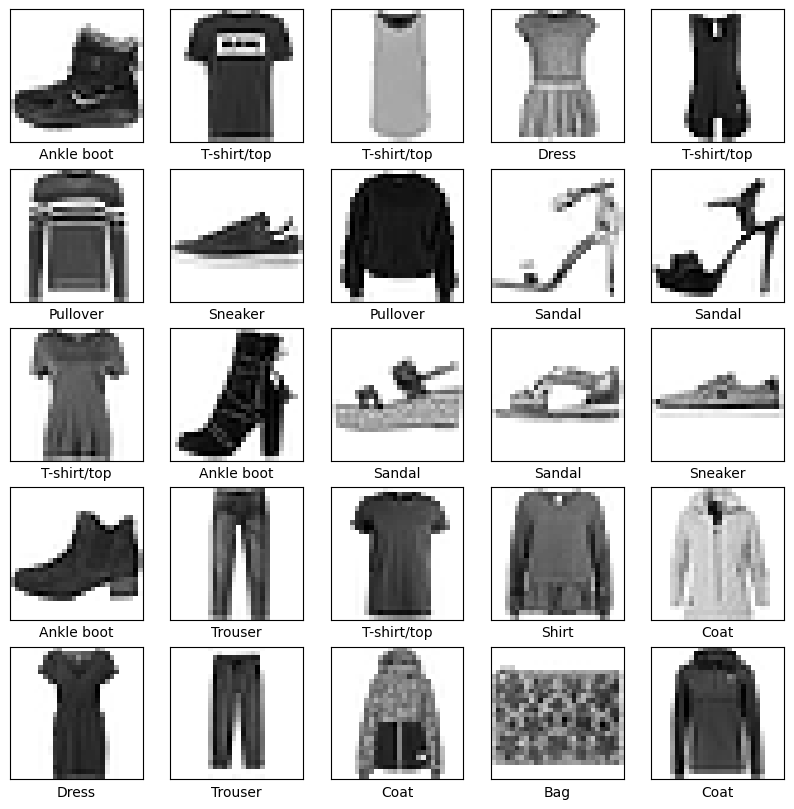

In [92]:
#Dibujar mas
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  imagen = imagen.numpy().reshape((28,28))
  etiqueta = int(etiqueta.numpy())
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(imagen, cmap=plt.cm.binary)
  plt.xlabel(nombres_clases[etiqueta])
plt.show()


## 3. Crear y entrenar el modelo

Construye la red neuronal, la compila y la entrena con los datos preparados.


In [93]:
#Crear el modelo
modelo = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 - blanco y negro
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(50, activation=tf.nn.relu),
  tf.keras.layers.Dense(10, activation=tf.nn.softmax) #Para redes de clasificacion
])

In [94]:
#Compilar el modelo
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [95]:
# Los numeros de datos en entrenamiento y pruebas (60k y 10k)
num_ej_entrenamiento = len(imagenes_entrenamiento)
num_ej_pruebas = len(imagenes_pruebas)


In [96]:
print(num_ej_entrenamiento)
print(num_ej_pruebas)

60000
10000


In [97]:
#El trabajo por lotes permite que entrenamientos con gran cantidad de datos se haga de manera mas eficiente
TAMANO_LOTE = 32

#Shuffle y repeat hacen que los datos esten mezclados de manera aleatoria para que la red
#no se vaya a aprender el orden de las cosas
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

In [98]:
import math

#Entrenar
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8166 - loss: 0.5233
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8583 - loss: 0.3900
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8737 - loss: 0.3462
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8807 - loss: 0.3254
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8831 - loss: 0.3171


## 4. Probar predicciones

Revisa la perdida y compara predicciones del modelo con imagenes del conjunto de prueba.


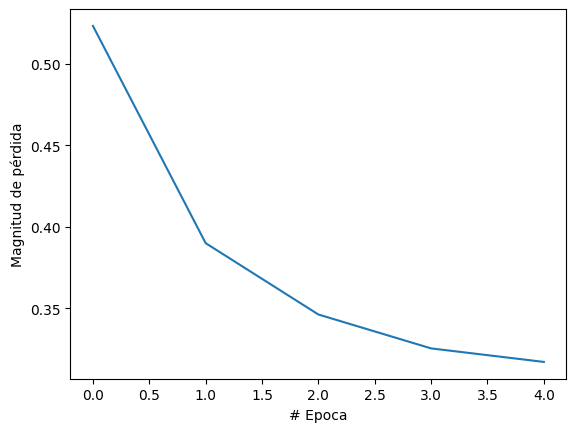

In [99]:
#Ver la funcion de perdida
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


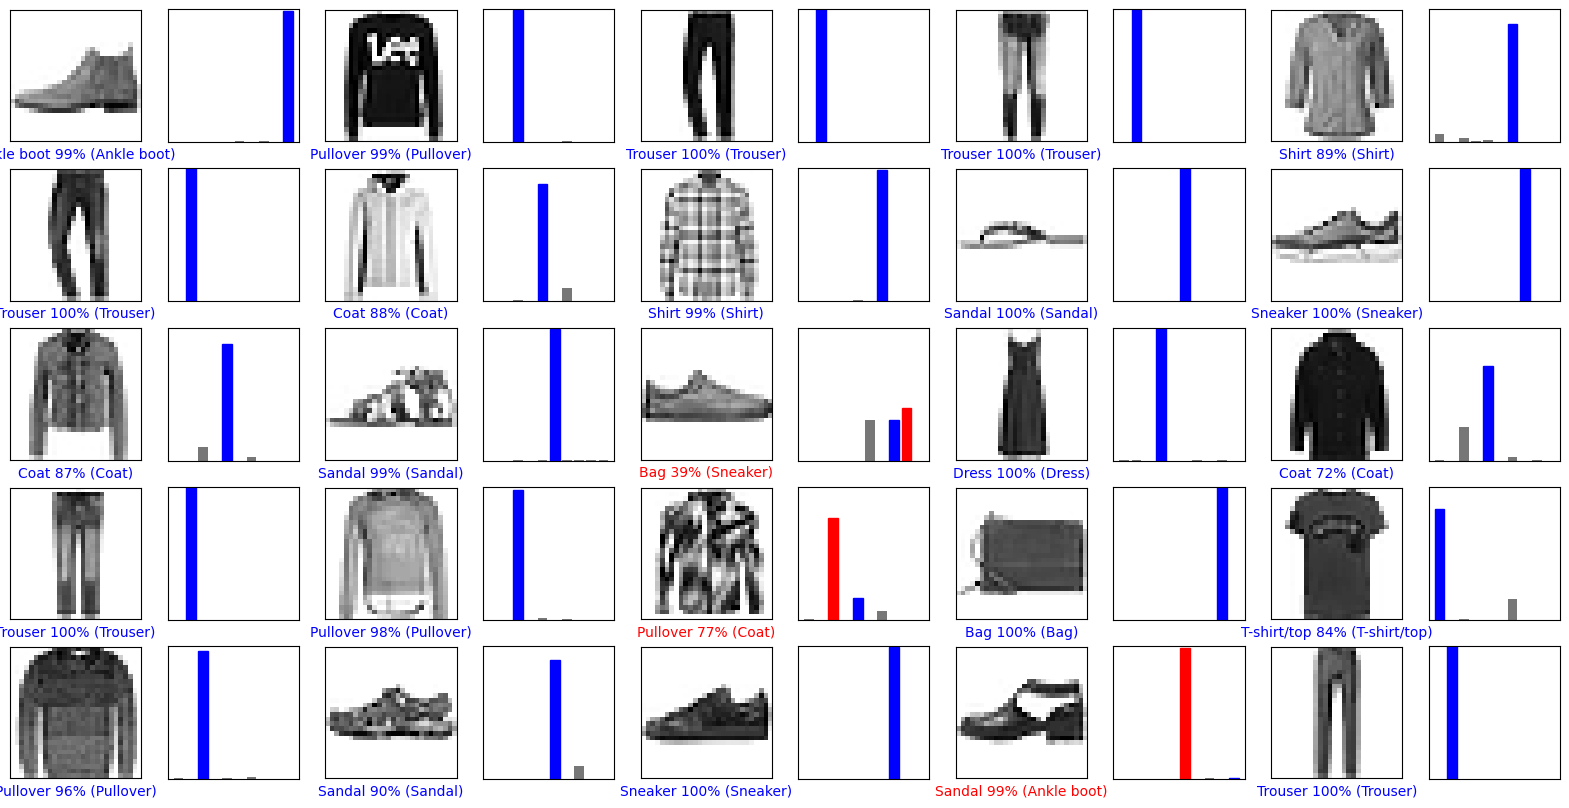

In [100]:
#Pintar una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
import numpy as np

for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                100*np.max(arr_predicciones),
                                nombres_clases[etiqueta_real]),
                                color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
  arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  grafica = plt.bar(range(10), arr_predicciones, color="#777777")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(arr_predicciones)

  grafica[etiqueta_prediccion].set_color('red')
  grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

In [101]:
#Probar una imagen suelta
imagen = imagenes_prueba[4] #AL ser la variable imagenes_prueba solo tiene lo que se le puso en el bloque anterior heheh
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Prediccion: " + nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Prediccion: Shirt


## 5. Exportar para TensorFlow.js

Guarda el modelo y lo convierte al formato que puede usarse en una pagina web.


In [102]:
#Exportacion del modelo a h5
modelo.save('modelo_exportado.h5')

In [103]:
# Instalar tensorflowjs para convertir el h5 a un modelo que pueda cargar tensorflowjs en un explorador
!pip install -q tensorflowjs


In [104]:
# Convertir el archivo h5 a formato de tensorflowjs
!mkdir -p tfjs_target_dir
!tensorflowjs_converter --input_format keras modelo_exportado.h5 tfjs_target_dir


2026-07-08 15:50:29.196079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783525829.214936    8156 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783525829.220393    8156 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783525829.238868    8156 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783525829.238912    8156 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783525829.238916    8156 computation_placer.cc:177] computation placer alr

In [105]:
#Veamos si si creo la carpeta
!ls

modelo_exportado.h5  sample_data  tfjs_target_dir


In [106]:
#Veamos el contenido de la carpeta
!ls tfjs_target_dir

group1-shard1of1.bin  model.json


In [108]:
from google.colab import files
import os

print("Archivos actuales en Colab:")
!ls

carpeta = "tfjs_target_dir"
zip_name = "modelo_tfjs.zip"

if os.path.exists(carpeta):
    print(f"\nCarpeta '{carpeta}' encontrada.")
    print("Comprimiendo modelo TensorFlow.js...")

    if os.path.exists(zip_name):
        os.remove(zip_name)

    !zip -r modelo_tfjs.zip tfjs_target_dir

    print("\nDescargando modelo_tfjs.zip a tu PC...")
    files.download(zip_name)

else:
    print(f"\nNo existe la carpeta '{carpeta}'.")

Archivos actuales en Colab:
modelo_exportado.h5  sample_data  tfjs_target_dir

Carpeta 'tfjs_target_dir' encontrada.
Comprimiendo modelo TensorFlow.js...
  adding: tfjs_target_dir/ (stored 0%)
  adding: tfjs_target_dir/model.json (deflated 77%)
  adding: tfjs_target_dir/group1-shard1of1.bin (deflated 7%)

Descargando modelo_tfjs.zip a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Anexos

### Documentacion de la app web

La aplicacion web funciona como interfaz de inferencia para el modelo entrenado con Fashion MNIST. El usuario puede dibujar una prenda en el canvas o subir una imagen, y el navegador procesa la entrada para generar una prediccion entre las 10 clases del dataset.

Flujo general:

1. Carga del modelo TensorFlow.js desde tfjs_target_dir/model.json.
2. Preprocesamiento de la imagen a 28 x 28 pixeles en escala de grises.
3. Prediccion con el modelo cargado en el navegador.
4. Visualizacion de probabilidades por clase.

Repositorio del proyecto:

[jeffersonmejia/clasificador-ropa](https://github.com/jeffersonmejia/clasificador-ropa)

### Deployment

La aplicacion fue desplegada como sitio estatico, ya que no requiere servidor backend ni base de datos. Solo necesita servir index.html, tfjs_target_dir/model.json y el archivo de pesos group1-shard1of1.bin.

Sitio publicado:

https://jeffersonmejia.github.io/clasificador-ropa/
